<a href="https://colab.research.google.com/github/Anjanique-Knight/AjGIS/blob/main/PS2_GIS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro

# Set Up

In [ ]:
#!pip install geopandas

import geopandas as gpd
import zipfile

In [ ]:
! wget -O njCO1.zip https://github.com/Anjanique-Knight/AjGIS/raw/refs/heads/main/NJ_Counties_3857_2520527434192953465.zip

--2026-10-08 22:06:12--  https://github.com/Anjanique-Knight/AjGIS/raw/refs/heads/main/NJ_Counties_3857_2520527434192953465.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Anjanique-Knight/AjGIS/refs/heads/main/NJ_Counties_3857_2520527434192953465.zip [following]
--2026-10-08 22:06:13--  https://raw.githubusercontent.com/Anjanique-Knight/AjGIS/refs/heads/main/NJ_Counties_3857_2520527434192953465.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2128431 (2.0M) [application/zip]
Saving to: ‘njCO1.zip’

njCO1.zip           100%[===================>]   2.03M  --.-KB/s    in 0.06s   

2026-10-0

In [ ]:
zip_ref = zipfile.ZipFile('njCO1.zip', 'r'); zip_ref.extractall(); zip_ref.close()

In [ ]:
gdf=gpd.read_file('NJ_Counties_3857.shp')

<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

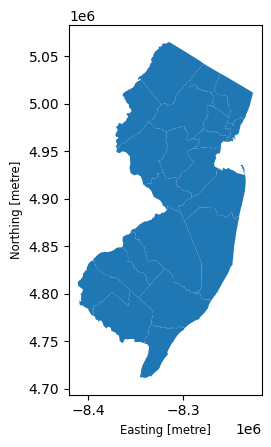

In [ ]:
gdf.plot()

In [ ]:
import pandas as pd


In [ ]:
gdf.head()

,COUNTY,COUNTY_LAB,CO,GNIS_NAME,GNIS,FIPSSTCO,FIPSCO,ACRES,SQ_MILES,POP2020,...,POP2000,POP1990,POP1980,POPDEN2020,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,REGION,geometry
0,ATLANTIC,Atlantic County,ATL,County of Atlantic,882270,34001,1,390813.840968,610.646627,274534,...,252552,275372,204615,450,450,414,451,335,COASTAL,"POLYGON ((-8312713.282 4820790.797, -8312708.3..."
1,BERGEN,Bergen County,BER,County of Bergen,882271,34003,3,153491.054911,239.829773,955732,...,884118,829592,849843,3985,3774,3686,3459,3544,NORTHEASTERN,"POLYGON ((-8227143.658 5009857.214, -8227168.3..."
2,BURLINGTON,Burlington County,BUR,County of Burlington,882272,34005,5,524901.239967,820.158187,461860,...,423394,395066,362542,563,547,516,482,442,SOUTHERN,"POLYGON ((-8315414.947 4892462.575, -8315385.2..."
3,CAMDEN,Camden County,CAM,County of Camden,882273,34007,7,145594.972008,227.492144,523485,...,508932,532498,471650,2301,2258,2237,2341,2073,SOUTHERN,"POLYGON ((-8352650.407 4865191.068, -8352634.3..."
4,CAPE MAY,Cape May County,CAP,County of Cape May,882274,34009,9,183125.841721,286.134128,95263,...,102326,95089,82266,333,340,358,332,288,COASTAL,"POLYGON ((-8333334.7 4767465.182, -8333326.647..."


# Isolating South Jersey

In [ ]:
snj_counties=['ATLANTIC', 'CUMBERLAND', 'CAMDEN', 'BURLINGTON', 'CAPE MAY', 'SALEM', 'GLOUCESTER', 'OCEAN']

In [ ]:
from numpy import copy
gdf[gdf['COUNTY'].isin(snj_counties)].copy

<bound method GeoDataFrame.copy of         COUNTY         COUNTY_LAB   CO             GNIS_NAME    GNIS FIPSSTCO  \
0     ATLANTIC    Atlantic County  ATL    County of Atlantic  882270    34001   
2   BURLINGTON  Burlington County  BUR  County of Burlington  882272    34005   
3       CAMDEN      Camden County  CAM      County of Camden  882273    34007   
4     CAPE MAY    Cape May County  CAP    County of Cape May  882274    34009   
5   CUMBERLAND  Cumberland County  CUM  County of Cumberland  882275    34011   
7   GLOUCESTER  Gloucester County  GLO  County of Gloucester  882277    34015   
14       OCEAN       Ocean County  OCE       County of Ocean  882279    34029   
16       SALEM       Salem County  SAL       County of Salem  882233    34033   

   FIPSCO          ACRES    SQ_MILES  POP2020  ...  POP2000  POP1990  POP1980  \
0       1  390813.840968  610.646627   274534  ...   252552   275372   204615   
2       5  524901.239967  820.158187   461860  ...   423394   395066   362542   
3       7  145594.972008  227.492144   523485  ...   508932   532498   471650   
4       9  183125.841721  286.134128    95263  ...   102326    95089    82266   
5      11  321149.036972  501.795370   154152  ...   146438   138053   132866   
7      15  215075.237102  336.055058   302294  ...   254673   230082   199917   
14     29  485076.500519  757.932032   637229  ...   510916   443424   356502   
16     33  222157.767414  347.121512    64837  ...    64285    65294    64676   

    POPDEN2020  POPDEN2010  POPDEN2000  POPDEN1990  POPDEN1980    REGION  \
0          450         450         414         451         335   COASTAL   
2          563         547         516         482         442  SOUTHERN   
3         2301        2258        2237        2341        2073  SOUTHERN   
4          333         340         358         332         288   COASTAL   
5          307         313         292         275         265  SOUTHERN   
7          900         858         758         685         595  SOUTHERN   
14         841         761         674         585         470   COASTAL   
16         187         190         185         188         186  SOUTHERN   

                                             geometry  
0   POLYGON ((-8312713.282 4820790.797, -8312708.3...  
2   POLYGON ((-8315414.947 4892462.575, -8315385.2...  
3   POLYGON ((-8352650.407 4865191.068, -8352634.3...  
4   POLYGON ((-8333334.7 4767465.182, -8333326.647...  
5   POLYGON ((-8355847.558 4803471.275, -8352785.3...  
7   POLYGON ((-8363274.44 4848913.536, -8363252.89...  
14  POLYGON ((-8266732.882 4890220.9, -8266724.401...  
16  POLYGON ((-8394264.296 4834757.726, -8394253.8...  

[8 rows x 21 columns]>

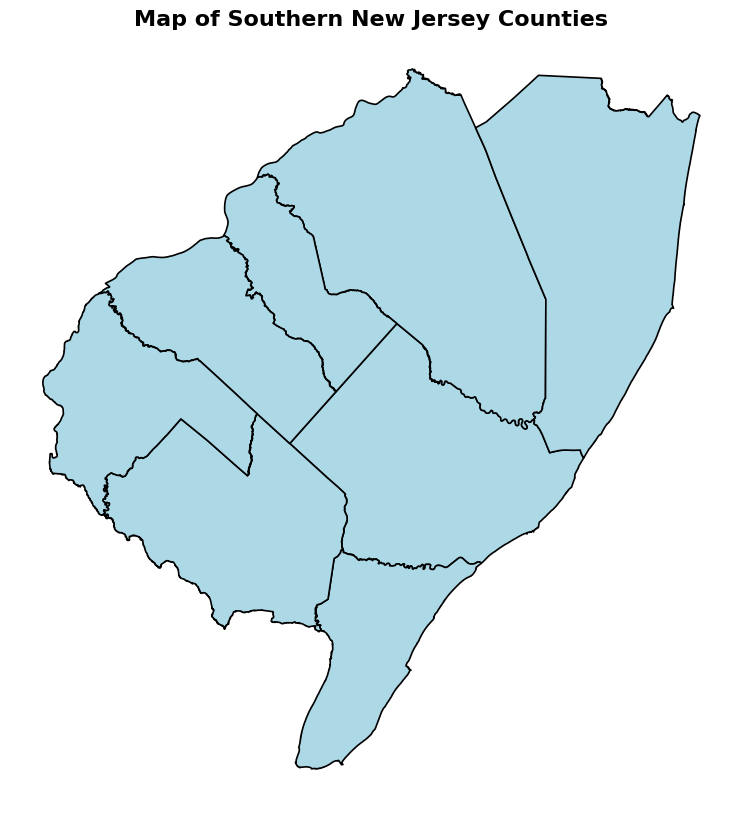

In [ ]:
import matplotlib.pyplot as plt

# Filter the GeoDataFrame to keep only the Southern NJ counties
snj_gdf = gdf[gdf['COUNTY'].isin(snj_counties)].copy()

fig, ax = plt.subplots(figsize=(10, 10))
snj_gdf.plot(ax=ax, edgecolor='black', color='lightblue', linewidth=1.2)

plt.title('Map of Southern New Jersey Counties', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

# Isolating Atlantic County

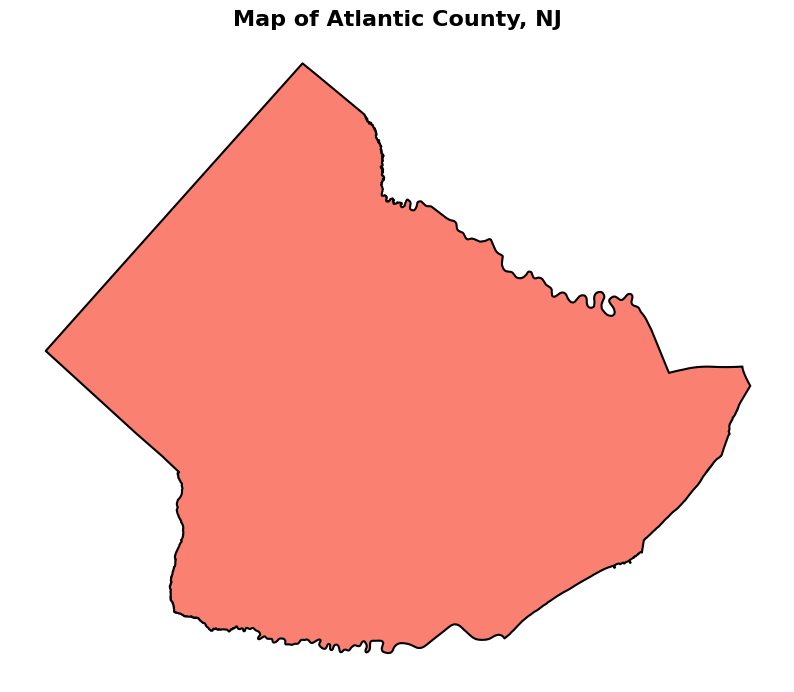

In [ ]:
ATLantic = snj_gdf[snj_gdf['COUNTY'] == 'ATLANTIC'].copy()
fig, ax = plt.subplots(figsize=(10, 10))
ATLantic.plot(ax=ax, edgecolor='black', color='salmon', linewidth=1.5)
plt.title('Map of Atlantic County, NJ', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

In [ ]:
! wget -q -O njMun.zip https://github.com/Anjanique-Knight/AjGIS/raw/refs/heads/main/NJ_Municipal_Boundaries_3424_-6792731789006169525.zip

In [ ]:
zip_ref = zipfile.ZipFile('njMun.zip', 'r'); zip_ref.extractall(); zip_ref.close()

In [ ]:
gdf=gpd.read_file('NJ_Municipal_Boundaries_3424.shp')

<Axes: xlabel='Easting [US survey foot]', ylabel='Northing [US survey foot]'>

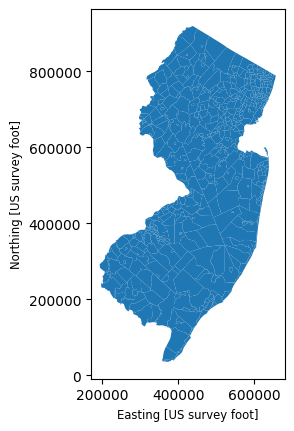

In [ ]:
gdf.plot()

In [ ]:
import pandas as pd


In [ ]:
gdf.head()

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,CENSUS2020,...,POP2010,POP2000,POP1990,POP1980,POPDEN2020,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,geometry
0,CAPE MAY POINT BORO,CAPE MAY,Cape May Point Borough,Borough,Cape May Point Borough,Borough of Cape May Point,885179,0503,0503,3400910330,...,291,241,248,255,1016,970,803,826,850,"POLYGON ((361324.555 36119.591, 361262.564 361..."
1,WEST CAPE MAY BORO,CAPE MAY,West Cape May Borough,Borough,West Cape May Borough,Borough of West Cape May,885435,0512,0512,3400978530,...,1024,1095,1026,1091,854,866,926,868,923,"POLYGON ((371013.281 40519.688, 372330.802 395..."
2,CAPE MAY CITY,CAPE MAY,Cape May City,City,Cape May,City of Cape May,885178,0502,0502,3400910270,...,3607,4034,4668,4853,960,1251,1399,1619,1684,"POLYGON ((385059.21 43411.44, 385135.71 43390...."
3,WILDWOOD CREST BORO,CAPE MAY,Wildwood Crest Borough,Borough,Wildwood Crest Borough,Borough of Wildwood Crest,885445,0515,0515,3400981200,...,3270,3980,3631,4149,2094,2208,2688,2452,2802,"POLYGON ((397386.178 55797.446, 397386.526 557..."
4,WEST WILDWOOD BORO,CAPE MAY,West Wildwood Borough,Borough,West Wildwood Borough,Borough of West Wildwood,885441,0513,0513,3400980210,...,603,448,453,360,1484,1657,1231,1245,990,"POLYGON ((401502.81 61708.99, 401592.22 61615...."


In [ ]:
# Filter to keep only municipalities in Atlantic County
atlantic_mun_gdf = gdf[gdf['COUNTY'] == 'ATLANTIC'].copy()

# Display the first few rows of the filtered GeoDataFrame
display(atlantic_mun_gdf.head())


,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,CENSUS2020,...,POP2010,POP2000,POP1990,POP1980,POPDEN2020,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,geometry
13,LONGPORT BORO,ATLANTIC,Longport Borough,Borough,Longport Borough,Borough of Longport,885286,0115,0115,3400141370,...,895,1054,1224,1249,1503,1507,1774,2060,2103,"POLYGON ((487673.252 176134.655, 487479.027 17..."
15,CORBIN CITY,ATLANTIC,Corbin City,City,Corbin City,City of Corbin City,885192,0106,0106,3400115160,...,492,468,412,254,52,55,52,46,28,"POLYGON ((422066.136 176339.873, 422075.89 176..."
16,SOMERS POINT CITY,ATLANTIC,Somers Point City,City,Somers Point,City of Somers Point,885397,0121,0121,3400168430,...,10795,11614,11216,10330,2104,2169,2334,2254,2076,"POLYGON ((464960.373 183097.251, 465071.67 182..."
17,MARGATE CITY,ATLANTIC,Margate City,City,Margate City,City of Margate City,885292,0116,0116,3400143890,...,6354,8193,8431,9179,3258,3893,5020,5166,5624,"POLYGON ((491565.71 185676.12, 491734.11 18545..."
20,VENTNOR CITY,ATLANTIC,Ventnor City,City,Ventnor City,City of Ventnor City,885426,0122,0122,3400175620,...,10650,12910,11005,11704,3613,4178,5064,4317,4591,"POLYGON ((494545.46 189258.23, 494708.26 18925..."


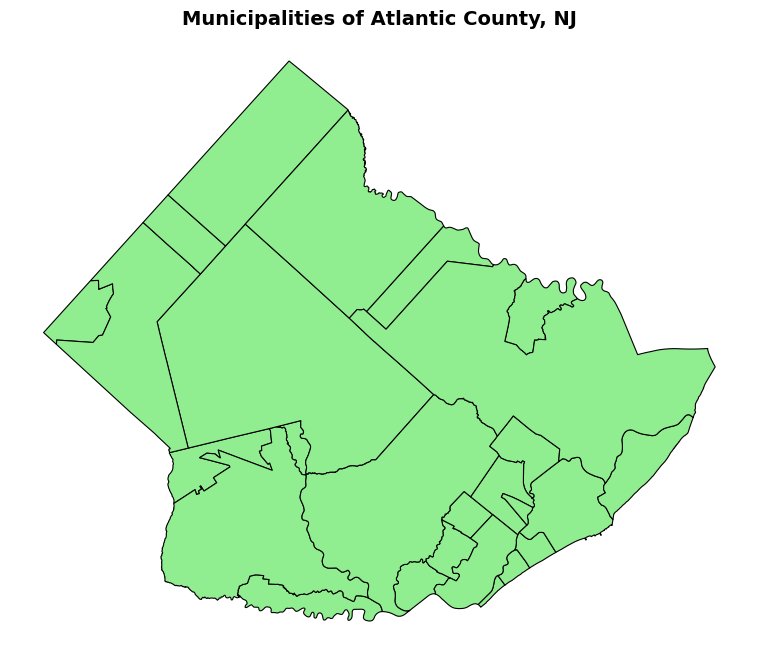

In [ ]:
# Filter and plot the municipalities of Atlantic County
import matplotlib.pyplot as plt

# Ensure the filtered GeoDataFrame is defined
atlantic_mun_gdf = gdf[gdf['COUNTY'] == 'ATLANTIC'].copy()

fig, ax = plt.subplots(figsize=(10, 8))
atlantic_mun_gdf.plot(ax=ax, edgecolor='black', color='lightgreen', linewidth=0.8)
plt.title('Municipalities of Atlantic County, NJ', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

#Geocoding Atlantic County Affordable Housing

In [ ]:
ATLhome=pd.read_excel('https://github.com/Anjanique-Knight/AjGIS/raw/refs/heads/main/atlantic.xlsx')
ATLhome=ATLhome[0:5]
ATLhome

,o,seq,ltd,source,notes,proj_no,pro_no_2,Unnamed: 7,development / aka,aka,...,phone,agent,agent address,area_2,phone_2,website,Unnamed: 35,program,date,seq.1
0,2,30001,NaN,HUD,NaN,NJ39Q971009,035HD084,NaN,Absecon consumer group home,NaN,...,780-1175,Collaborative Support Programs of NJ,"11 Spring St, Freehold 08977",(908),272-5365,CSPNJ,NaN,Section 202,NaT,30001
1,3,30002,NaN,HUD,NaN,NJ39Q081006,035HD069,NaN,Caring group home (2008),NaN,...,484-7050,Caring Inc,"407 W Delilah Rd, Pleasantville 08232",(609),677-0022,Home (caringinc.net),NaN,Section 202,NaT,30002
2,4,30003,NaN,HUD,NaN,NJ39Q101004,035HD074,NaN,Caring group home (2010),NaN,...,484-7050,Caring Inc,"407 W Delilah Rd, Pleasantville 08232",(609),677-0022,Home (caringinc.net),NaN,Section 202,NaT,30003
3,5,20001,NaN,tax credit,NaN,010109937,NaN,NaN,Clayton Mill Run Apts,5 bldgs; facility id 010109937,...,385-2745,Conifer Realty,"20000 Horizon Way, ste 180, Mount Laurel 08054",(856),793-2078,Clayton Mill Run - Conifer Realty LLC (conifer...,NaN,tax credit / MtL,NaT,20001
4,6,30005,NaN,HUD,NaN,NJ39RDD1317,NaN,NaN,Visions at Absecon Family & Senior Apts,1 bldg; 24 du,...,780-8314,D & M Property Mgt,"655 Park Av, Freehold 07728",NaN,NaN,NaN,NaN,NaN,NaT,30005


In [ ]:
from geopandas.tools import geocode

In [ ]:
# Filter out rows with placeholder street names like 'intentional blank'
valid_homes = ATLhome[~ATLhome['street'].astype(str).str.contains('intentional blank', case=False, na=True)].copy()

# Combine valid street, 'City ', and state into address strings
full_addresses = valid_homes['street'].astype(str) + ', ' + valid_homes['City '].astype(str) + ', NJ'

# Geocode the valid addresses
ATLgeo = geocode(full_addresses, provider='nominatim', user_agent='Aj', timeout=5)
ATLgeo.head()

,geometry,address
3,POINT (-74.51256 39.41702),"Rose Hill Drive, Absecon, Atlantic County, New..."
4,POINT (-74.49304 39.43958),"3, School View Drive, Mi-Place at the Shore, A..."


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

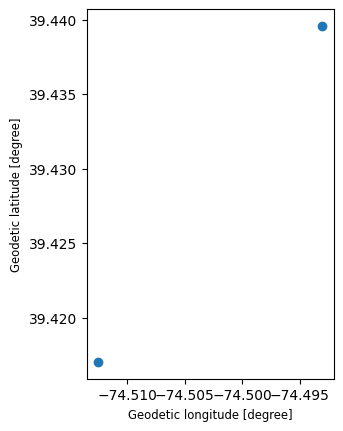

In [ ]:
ATLgeo.plot()

In [ ]:
import time
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# 1. Load the FULL dataset without slicing
ATLhome_full = pd.read_excel('https://github.com/Anjanique-Knight/AjGIS/raw/refs/heads/main/atlantic.xlsx')

# 2. Filter out rows with placeholder street names like 'intentional blank'
valid_homes_full = ATLhome_full[
    ~ATLhome_full['street'].astype(str).str.contains('intentional blank', case=False, na=True)
].copy()

# 3. Combine valid street, 'City ', and state into full address strings
valid_homes_full['full_address'] = valid_homes_full['street'].astype(str) + ', ' + valid_homes_full['City '].astype(str) + ', NJ'

# 4. Initialize Nominatim Geocoder and RateLimiter to enforce 1 second per request
geolocator = Nominatim(user_agent="nj_affordable_housing_mapper_aj")
geocode_with_delay = RateLimiter(geolocator.geocode, min_delay_seconds=1.1, return_value_on_exception=None)

# 5. Geocode the addresses
print(f"Geocoding {len(valid_homes_full)} addresses with a rate-limit delay (takes about 1.5 - 2 minutes). Please wait...")
valid_homes_full['location'] = valid_homes_full['full_address'].apply(geocode_with_delay)

# 6. Extract geometry and clean up results
valid_homes_full['point'] = valid_homes_full['location'].apply(lambda loc: Point(loc.longitude, loc.latitude) if loc else None)
valid_homes_full['address_matched'] = valid_homes_full['location'].apply(lambda loc: loc.address if loc else None)

# Drop rows that failed to geocode
final_geocoded = valid_homes_full.dropna(subset=['point']).copy()

# Convert to GeoDataFrame
ATLgeo_full = gpd.GeoDataFrame(final_geocoded, geometry='point', crs="EPSG:4326")

# Configure pandas to show all rows in display
pd.set_option('display.max_rows', None)

# Display the entire geocoded address list
display(ATLgeo_full[['street', 'City ', 'address_matched', 'geometry']])

Geocoding 92 addresses with a rate-limit delay (takes about 1.5 - 2 minutes). Please wait...


Streaming output truncated to the last 5000 lines.
    retries = retries.increment(
        method, url, error=new_e, _pool=self, _stacktrace=sys.exc_info()[2]
    )
  File "/usr/local/lib/python3.13/dist-packages/urllib3/util/retry.py", line 519, in increment
    raise MaxRetryError(_pool, url, reason) from reason  # type: ignore[arg-type]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
urllib3.exceptions.MaxRetryError: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=721+N+Atlantic+Av%2C+Atlantic+City%2C+NJ&format=json&limit=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/geopy/adapters.py", line 482, in _request
    resp = self.session.get(url, timeout=timeout, headers=headers)
  Fi

KeyError: "['geometry'] not in index"

https://www.arcgis.com/home/item.html?id=95177982e99e46778881d34cb9ac4d99&sublayer=0

https://www.policymap.com/newmaps/e/rutgers

https://www.nj.gov/health/fhs/primarycare/rural-health/DesignatedRuralAreasinNewJersey.pdf